# Sparse Pixel Image-to-Image CNN

This notebook demonstrates **sparse pixel supervision** for image-to-image tasks using a U-Net-like CNN.

## Overview
- **Input**: Images with missing/masked pixels
- **Output**: Pixel-level predictions with sparse supervision (only some pixels have labels)
- **Task**: Image reconstruction/completion from sparse observations

## Masking Strategy
Our sparse pixel approach uses a **dual masking system**:

1. **Input Masking**: Random pixels are set to zero to simulate missing data (e.g., cloud cover, sensor failures). We use ~40% visible pixels to simulate realistic satellite imagery conditions.

2. **Output Masking**: Only a sparse subset (~15%) of output pixels have ground truth labels for supervision. This simulates scenarios where expensive manual labeling is only available for select locations.

**Implementation Details**:
- Input masks are created by randomly selecting pixels with probability `input_sparsity` 
- Output masks are independently created with probability `output_sparsity`
- Loss computation only considers labeled pixels (output mask = 1)
- Model predicts full images but is trained only on sparse supervision

## 1. Setup and Imports

First, let's import the necessary libraries and our custom sparse pixel classes.

In [29]:
# Standard imports
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
from typing import Tuple, Optional

# Add the examples directory to path
sys.path.append('../examples')

# PyTorch imports
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader
import torchvision.transforms as transforms

# Import our custom classes for sparse pixel tasks
from sparse_pixel_example import SparsePixelDataset, UNetCNN, sparse_pixel_loss

print(f"PyTorch version: {torch.__version__}")
print(f"Device available: {'GPU' if torch.cuda.is_available() else 'CPU'}")

PyTorch version: 2.6.0+cu124
Device available: GPU


## 2. Configuration and Dataset Creation

Let's configure our sparse pixel experiment with realistic sparsity levels.

In [20]:
# Configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
batch_size = 16
input_sparsity = 0.4   # 40% of input pixels are visible (rest masked)
output_sparsity = 0.15  # 15% of output pixels have target labels
num_epochs = 5

# Data transforms (keep in [0,1] range for easy visualization)
transform = transforms.Compose([
    transforms.ToTensor(),
])

print(f"Configuration:")
print(f"  Device: {device}")
print(f"  Batch size: {batch_size}")  
print(f"  Input sparsity: {input_sparsity*100}% pixels visible")
print(f"  Output sparsity: {output_sparsity*100}% pixels labeled")
print(f"  Training epochs: {num_epochs}")
print(f"\nThis simulates:")
print(f"  • {100-input_sparsity*100}% of input pixels missing (clouds/sensor failure)")
print(f"  • Only {output_sparsity*100}% of pixels have ground truth labels")

Configuration:
  Device: cuda
  Batch size: 16
  Input sparsity: 40.0% pixels visible
  Output sparsity: 15.0% pixels labeled
  Training epochs: 5

This simulates:
  • 60.0% of input pixels missing (clouds/sensor failure)
  • Only 15.0% of pixels have ground truth labels


In [21]:
# Create sparse pixel datasets
print("Creating sparse pixel datasets...")

train_dataset = SparsePixelDataset(
    root='./data', 
    train=True,
    input_sparsity=input_sparsity,
    output_sparsity=output_sparsity,
    transform=transform, 
    download=True
)

test_dataset = SparsePixelDataset(
    root='./data', 
    train=False,
    input_sparsity=input_sparsity,
    output_sparsity=output_sparsity,
    transform=transform, 
    download=False
)

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"\nDataset sizes:")
print(f"  Training: {len(train_dataset)} samples")
print(f"  Test: {len(test_dataset)} samples")
print(f"  Avg labeled pixels per image: ~{int(32*32*output_sparsity)} out of {32*32}")
print(f"  Avg visible input pixels per image: ~{int(32*32*input_sparsity)} out of {32*32}")

Creating sparse pixel datasets...
Created SparsePixelDataset:
  Input sparsity: 40.0% pixels visible
  Output sparsity: 15.0% pixels labeled
  Dataset size: 50000 samples
Created SparsePixelDataset:
  Input sparsity: 40.0% pixels visible
  Output sparsity: 15.0% pixels labeled
  Dataset size: 10000 samples

Dataset sizes:
  Training: 50000 samples
  Test: 10000 samples
  Avg labeled pixels per image: ~153 out of 1024
  Avg visible input pixels per image: ~409 out of 1024


## 3. Data Visualization

Let's visualize the sparse pixel setup - input images with missing pixels and target images with sparse labels.

Visualizing sparse pixel data structure...
Debug sample 0: inp_mask shape=(32, 32), dtype=bool
Debug sample 0: out_mask shape=(32, 32), dtype=bool
Debug sample 1: inp_mask shape=(32, 32), dtype=bool
Debug sample 1: out_mask shape=(32, 32), dtype=bool
Debug sample 2: inp_mask shape=(32, 32), dtype=bool
Debug sample 2: out_mask shape=(32, 32), dtype=bool
Debug sample 3: inp_mask shape=(32, 32), dtype=bool
Debug sample 3: out_mask shape=(32, 32), dtype=bool


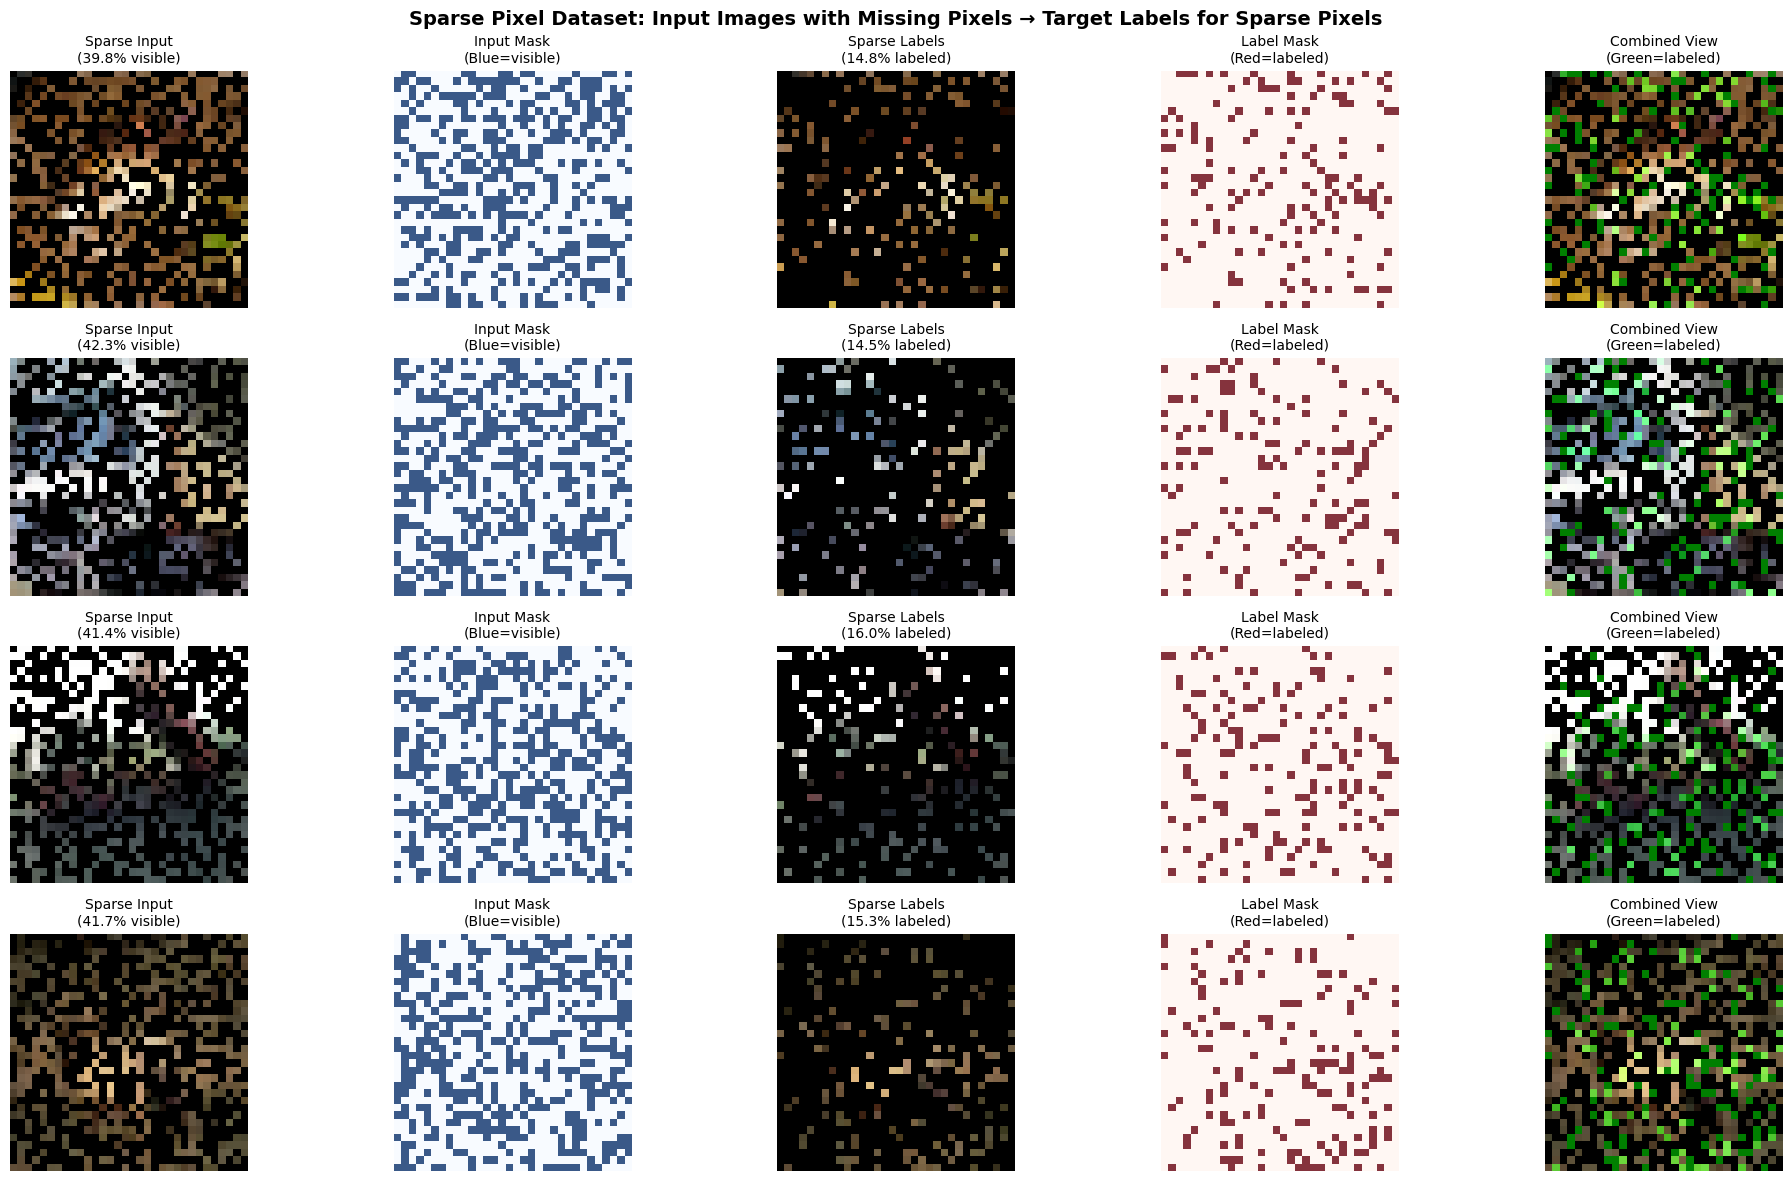

In [22]:
def visualize_sparse_pixel_data(dataset, num_samples=6):
    """Visualize sparse pixel input/output pairs."""
    
    fig, axes = plt.subplots(num_samples, 5, figsize=(20, num_samples*3))
    if num_samples == 1:
        axes = axes.reshape(1, -1)
    
    for i in range(num_samples):
        sparse_input, sparse_target, input_mask, output_mask = dataset[i]
        
        # Convert to numpy for visualization and ensure correct types
        sparse_inp = sparse_input.permute(1, 2, 0).numpy()
        sparse_tgt = sparse_target.permute(1, 2, 0).numpy()
        inp_mask = input_mask.numpy().astype(bool)  # Ensure boolean type
        out_mask = output_mask.numpy().astype(bool)  # Ensure boolean type
        
        print(f"Debug sample {i}: inp_mask shape={inp_mask.shape}, dtype={inp_mask.dtype}")
        print(f"Debug sample {i}: out_mask shape={out_mask.shape}, dtype={out_mask.dtype}")
        
        # Original target (for comparison)
        original_target = sparse_tgt.copy()
        original_target[sparse_tgt == -1] = 0  # Replace -1 with 0 for visualization
        
        # 1. Sparse input (with missing pixels)
        axes[i, 0].imshow(np.clip(sparse_inp, 0, 1))
        axes[i, 0].set_title(f'Sparse Input\n({inp_mask.mean()*100:.1f}% visible)', fontsize=10)
        axes[i, 0].axis('off')
        
        # 2. Input mask
        axes[i, 1].imshow(inp_mask, cmap='Blues', alpha=0.8)
        axes[i, 1].set_title('Input Mask\n(Blue=visible)', fontsize=10)
        axes[i, 1].axis('off')
        
        # 3. Sparse target labels
        axes[i, 2].imshow(np.clip(original_target, 0, 1))
        axes[i, 2].set_title(f'Sparse Labels\n({out_mask.mean()*100:.1f}% labeled)', fontsize=10)
        axes[i, 2].axis('off')
        
        # 4. Output mask
        axes[i, 3].imshow(out_mask, cmap='Reds', alpha=0.8)
        axes[i, 3].set_title('Label Mask\n(Red=labeled)', fontsize=10)
        axes[i, 3].axis('off')
        
        # 5. Combined visualization - simplified approach
        combined = sparse_inp.copy()  # Start with sparse input
        
        # Create overlay for labeled pixels (make them more visible)
        if out_mask.any():
            overlay = np.zeros_like(sparse_inp)
            overlay[out_mask] = [0, 0.5, 0]  # Green overlay for labeled pixels
            combined = np.clip(combined + overlay, 0, 1)
        
        axes[i, 4].imshow(np.clip(combined, 0, 1))
        axes[i, 4].set_title('Combined View\n(Green=labeled)', fontsize=10)
        axes[i, 4].axis('off')
    
    plt.suptitle('Sparse Pixel Dataset: Input Images with Missing Pixels → Target Labels for Sparse Pixels', 
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

# Visualize the dataset
print("Visualizing sparse pixel data structure...")
visualize_sparse_pixel_data(train_dataset, num_samples=4)

## 4. Model Creation and Architecture

Let's create our U-Net CNN and examine its architecture.

In [23]:
# Create U-Net model for pixel-to-pixel prediction
model = UNetCNN(in_channels=3, out_channels=3, base_filters=32).to(device)

# Print model architecture summary
print("U-Net CNN Architecture:")
print("=" * 50)
print(model)
print("=" * 50)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"\nModel Statistics:")
print(f"  Total parameters: {total_params:,}")
print(f"  Trainable parameters: {trainable_params:,}")
print(f"  Model size (MB): {total_params * 4 / (1024**2):.2f}")
print(f"\nArchitecture: U-Net with skip connections")
print(f"  • Encoder: 3 downsampling layers")
print(f"  • Bottleneck: Deep feature extraction")
print(f"  • Decoder: 3 upsampling layers with skip connections")
print(f"  • Output: Sigmoid activation for [0,1] pixel values")

U-Net CNN Architecture:
UNetCNN(
  (enc1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
  )
  (enc2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
  )
  (enc3): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1,

## 5. Training Loop

Now let's train our model using sparse pixel supervision.

In [24]:
# Training setup for sparse pixel image-to-image task
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Track training progress
train_losses = []
train_mse_values = []
total_labeled_pixels_per_epoch = []

print("Starting sparse pixel training...")
print("=" * 60)

model.train()

for epoch in range(num_epochs):
    epoch_loss = 0.0
    epoch_mse = 0.0
    epoch_labeled_pixels = 0
    batch_count = 0
    
    for batch_idx, (sparse_inputs, sparse_targets, input_masks, output_masks) in enumerate(train_loader):
        # Move to device
        sparse_inputs = sparse_inputs.to(device)
        sparse_targets = sparse_targets.to(device)
        input_masks = input_masks.to(device)
        output_masks = output_masks.to(device)
        
        # Forward pass - predict full images
        optimizer.zero_grad()
        predicted_images = model(sparse_inputs)
        
        # Calculate sparse pixel loss (only on labeled pixels)
        loss = sparse_pixel_loss(predicted_images, sparse_targets, output_masks)
        
        if loss is not None:  # Only if there are labeled pixels in the batch
            loss.backward()
            optimizer.step()
            
            # Track statistics
            epoch_loss += loss.item()
            batch_count += 1
            
            # Calculate MSE on labeled pixels (better metric for regression)
            with torch.no_grad():
                # Convert to [0,1] range for comparison
                pred_clamped = torch.clamp(predicted_images, 0, 1)
                target_clamped = torch.clamp(sparse_targets, 0, 1)
                
                # Calculate MSE per pixel on labeled pixels only
                pixel_mse = F.mse_loss(pred_clamped, target_clamped, reduction='none')
                pixel_mse_mean = pixel_mse.mean(dim=1)  # Average over color channels
                
                # Only consider labeled pixels for MSE calculation
                labeled_pixel_mse = pixel_mse_mean[output_masks.bool()].mean()
                if not torch.isnan(labeled_pixel_mse):
                    epoch_mse += labeled_pixel_mse.item()
                
                epoch_labeled_pixels += output_masks.sum().item()
            
            # Print progress every 500 batches (less verbose)
            if batch_idx % 500 == 0:
                labeled_pixels_in_batch = int(output_masks.sum().item())
                print(f'  Epoch {epoch+1}, Batch {batch_idx:4d}: Loss={loss.item():.4f}, '
                      f'Labeled pixels={labeled_pixels_in_batch:4d}')
    
    # Calculate epoch metrics
    if batch_count > 0:
        avg_loss = epoch_loss / batch_count
        avg_mse = epoch_mse / batch_count
    else:
        avg_loss = 0.0
        avg_mse = 0.0
    
    train_losses.append(avg_loss)
    train_mse_values.append(avg_mse)
    total_labeled_pixels_per_epoch.append(epoch_labeled_pixels)
    
    print(f"\nEpoch {epoch+1}/{num_epochs} Completed:")
    print(f"  Average Loss: {avg_loss:.4f}")
    print(f"  Average MSE: {avg_mse:.6f}")
    print(f"  RMSE: {np.sqrt(avg_mse):.6f}")
    print(f"  Labeled pixels processed: {int(epoch_labeled_pixels):,}")
    print(f"  Batches processed: {batch_count}/{len(train_loader)}")
    print("-" * 50)

print("\nTraining completed!")
print(f"Final MSE: {train_mse_values[-1]:.6f}")
print(f"Final RMSE: {np.sqrt(train_mse_values[-1]):.6f}")
print("This simulates federated learning with sparse pixel supervision!")

Starting sparse pixel training...
  Epoch 1, Batch    0: Loss=0.0812, Labeled pixels=2487
  Epoch 1, Batch  500: Loss=0.0046, Labeled pixels=2459
  Epoch 1, Batch 1000: Loss=0.0042, Labeled pixels=2322
  Epoch 1, Batch 1500: Loss=0.0030, Labeled pixels=2485
  Epoch 1, Batch 2000: Loss=0.0034, Labeled pixels=2489
  Epoch 1, Batch 2500: Loss=0.0041, Labeled pixels=2448
  Epoch 1, Batch 3000: Loss=0.0033, Labeled pixels=2434

Epoch 1/5 Completed:
  Average Loss: 0.0047
  Average MSE: 0.004690
  RMSE: 0.068483
  Labeled pixels processed: 7,676,252
  Batches processed: 3125/3125
--------------------------------------------------
  Epoch 2, Batch    0: Loss=0.0026, Labeled pixels=2396
  Epoch 2, Batch  500: Loss=0.0028, Labeled pixels=2494
  Epoch 2, Batch 1000: Loss=0.0035, Labeled pixels=2457
  Epoch 2, Batch 1500: Loss=0.0037, Labeled pixels=2459
  Epoch 2, Batch 2000: Loss=0.0029, Labeled pixels=2390
  Epoch 2, Batch 2500: Loss=0.0035, Labeled pixels=2376
  Epoch 2, Batch 3000: Loss=0.00

## 6. Training Visualization

Let's visualize the training progress.

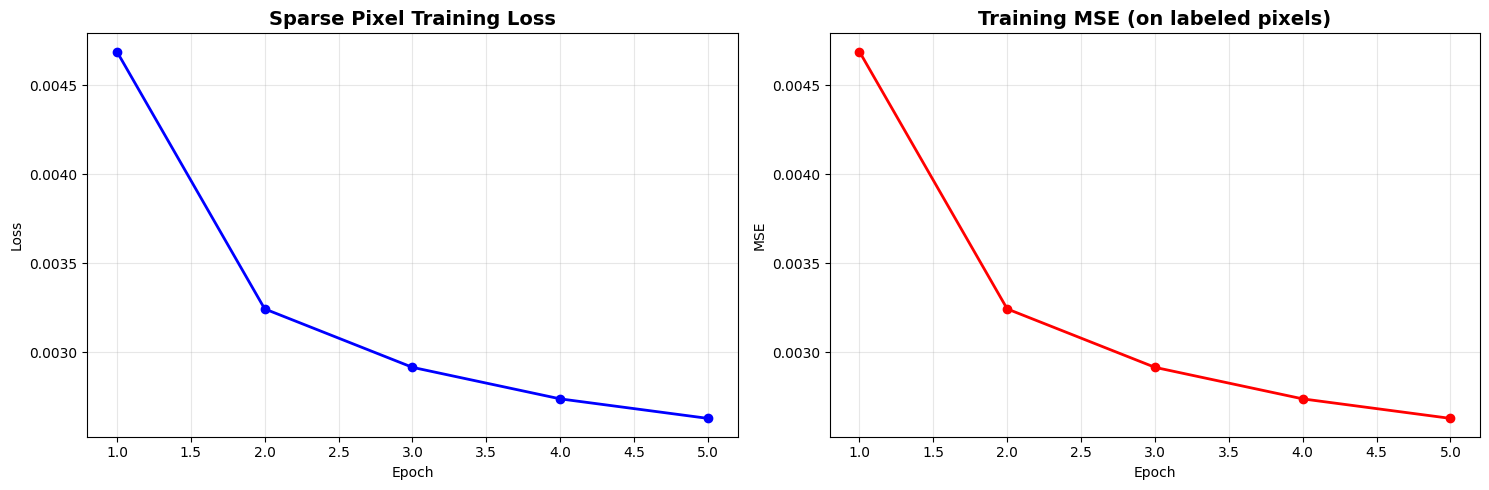


Final Sparse Pixel Training Statistics:
  Final Loss: 0.0026
  Final MSE: 0.002628
  Final RMSE: 0.051264
  Total labeled pixels processed in last epoch: 7,681,926
  Training completed for 5 epochs


In [25]:
# Plot training curves for sparse pixel training
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Check if we have training data to plot
if len(train_losses) > 0 and len(train_mse_values) > 0:
    # Loss curve
    epochs = range(1, len(train_losses) + 1)
    ax1.plot(epochs, train_losses, 'b-o', linewidth=2, markersize=6)
    ax1.set_title('Sparse Pixel Training Loss', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.grid(True, alpha=0.3)

    # MSE curve (better metric for regression)
    ax2.plot(epochs, train_mse_values, 'r-o', linewidth=2, markersize=6)
    ax2.set_title('Training MSE (on labeled pixels)', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('MSE')
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Print final training stats
    print(f"\nFinal Sparse Pixel Training Statistics:")
    print(f"  Final Loss: {train_losses[-1]:.4f}")
    print(f"  Final MSE: {train_mse_values[-1]:.6f}")
    print(f"  Final RMSE: {np.sqrt(train_mse_values[-1]):.6f}")
    print(f"  Total labeled pixels processed in last epoch: {int(total_labeled_pixels_per_epoch[-1]):,}")
    print(f"  Training completed for {len(train_losses)} epochs")
else:
    print("⚠️  No training data available to plot.")
    print("   Please run the training cell first to generate the training curves.")
    print(f"   Current state: train_losses has {len(train_losses)} values")
    print(f"                 train_mse_values has {len(train_mse_values)} values")

## 7. Model Evaluation

Now let's evaluate our trained model on the full test set.

In [26]:
# Evaluate the trained model on test set
print("Evaluating sparse pixel model on test set...")

model.eval()
test_losses = []
test_mse_values = []
pixel_mse_values = []
total_labeled_test_pixels = 0
total_test_pixels = 0

with torch.no_grad():
    for sparse_inputs, sparse_targets, input_masks, output_masks in test_loader:
        # Move to device
        sparse_inputs = sparse_inputs.to(device)
        sparse_targets = sparse_targets.to(device)
        input_masks = input_masks.to(device)
        output_masks = output_masks.to(device)
        
        # Forward pass
        predicted_images = model(sparse_inputs)
        
        # Calculate loss only on labeled pixels
        loss = sparse_pixel_loss(predicted_images, sparse_targets, output_masks)
        if loss is not None:
            test_losses.append(loss.item())
        
        # Calculate MSE for labeled pixels
        pred_clamped = torch.clamp(predicted_images, 0, 1)
        target_clamped = torch.clamp(sparse_targets, 0, 1)
        
        # Iterate through batch to handle boolean indexing correctly
        for b in range(pred_clamped.shape[0]):
            # Get the mask for this image
            item_mask = output_masks[b].bool()
            
            if item_mask.sum() > 0:  # If there are labeled pixels
                # Get MSE for labeled pixels only
                item_mse = F.mse_loss(pred_clamped[b], target_clamped[b], reduction='none')
                item_mse = item_mse.mean(dim=0)  # Average over color channels
                
                # Extract MSE values for labeled pixels
                labeled_mse_values = item_mse[item_mask]
                pixel_mse_values.extend(labeled_mse_values.cpu().numpy())
                
                # Calculate batch-level MSE
                batch_mse = labeled_mse_values.mean().item()
                test_mse_values.append(batch_mse)
                
                total_labeled_test_pixels += item_mask.sum().item()
                total_test_pixels += item_mask.numel()

# Calculate final metrics
avg_test_loss = np.mean(test_losses) if len(test_losses) > 0 else 0.0
avg_test_mse = np.mean(test_mse_values) if len(test_mse_values) > 0 else 0.0
avg_pixel_mse = np.mean(pixel_mse_values) if len(pixel_mse_values) > 0 else 0.0
test_rmse = np.sqrt(avg_test_mse) if avg_test_mse > 0 else 0.0
test_sparsity = total_labeled_test_pixels / max(1, total_test_pixels)

# Calculate PSNR (Peak Signal-to-Noise Ratio) - common image quality metric
# PSNR = 20 * log10(MAX_I) - 10 * log10(MSE)
# For images normalized to [0,1], MAX_I = 1
test_psnr = 20 * np.log10(1.0) - 10 * np.log10(avg_pixel_mse) if avg_pixel_mse > 0 else float('inf')

# Print clean, formatted results
print("\nTest Set Evaluation Results:")
print("=" * 50)
print(f"Test Loss (labeled pixels): {avg_test_loss:.4f}")
print(f"Test MSE: {avg_test_mse:.6f}")
print(f"Test RMSE: {test_rmse:.6f}")
print(f"Test PSNR: {test_psnr:.2f} dB")
print(f"Test Sparsity: {test_sparsity*100:.1f}% labeled")
print(f"Total Test Batches: {len(test_loader)}")

if len(pixel_mse_values) > 0:
    print(f"\nPixel-level MSE Statistics:")
    print(f"  Min MSE: {min(pixel_mse_values):.6f}")
    print(f"  Max MSE: {max(pixel_mse_values):.6f}")
    print(f"  Median MSE: {np.median(pixel_mse_values):.6f}")
    print(f"  Standard Deviation: {np.std(pixel_mse_values):.6f}")

print(f"\nEvaluation complete - regression quality metrics")
print(f"for sparse supervision federated learning scenario.")
print(f"PSNR > 30 dB is generally considered good image quality.")

Evaluating sparse pixel model on test set...

Test Set Evaluation Results:
Test Loss (labeled pixels): 0.0023
Test MSE: 0.002304
Test RMSE: 0.048003
Test PSNR: 26.38 dB
Test Sparsity: 15.0% labeled
Total Test Batches: 625

Pixel-level MSE Statistics:
  Min MSE: 0.000000
  Max MSE: 0.656946
  Median MSE: 0.000293
  Standard Deviation: 0.008155

Evaluation complete - regression quality metrics
for sparse supervision federated learning scenario.
PSNR > 30 dB is generally considered good image quality.


## 8. Results Visualization

Let's create comprehensive visualizations of our training results.

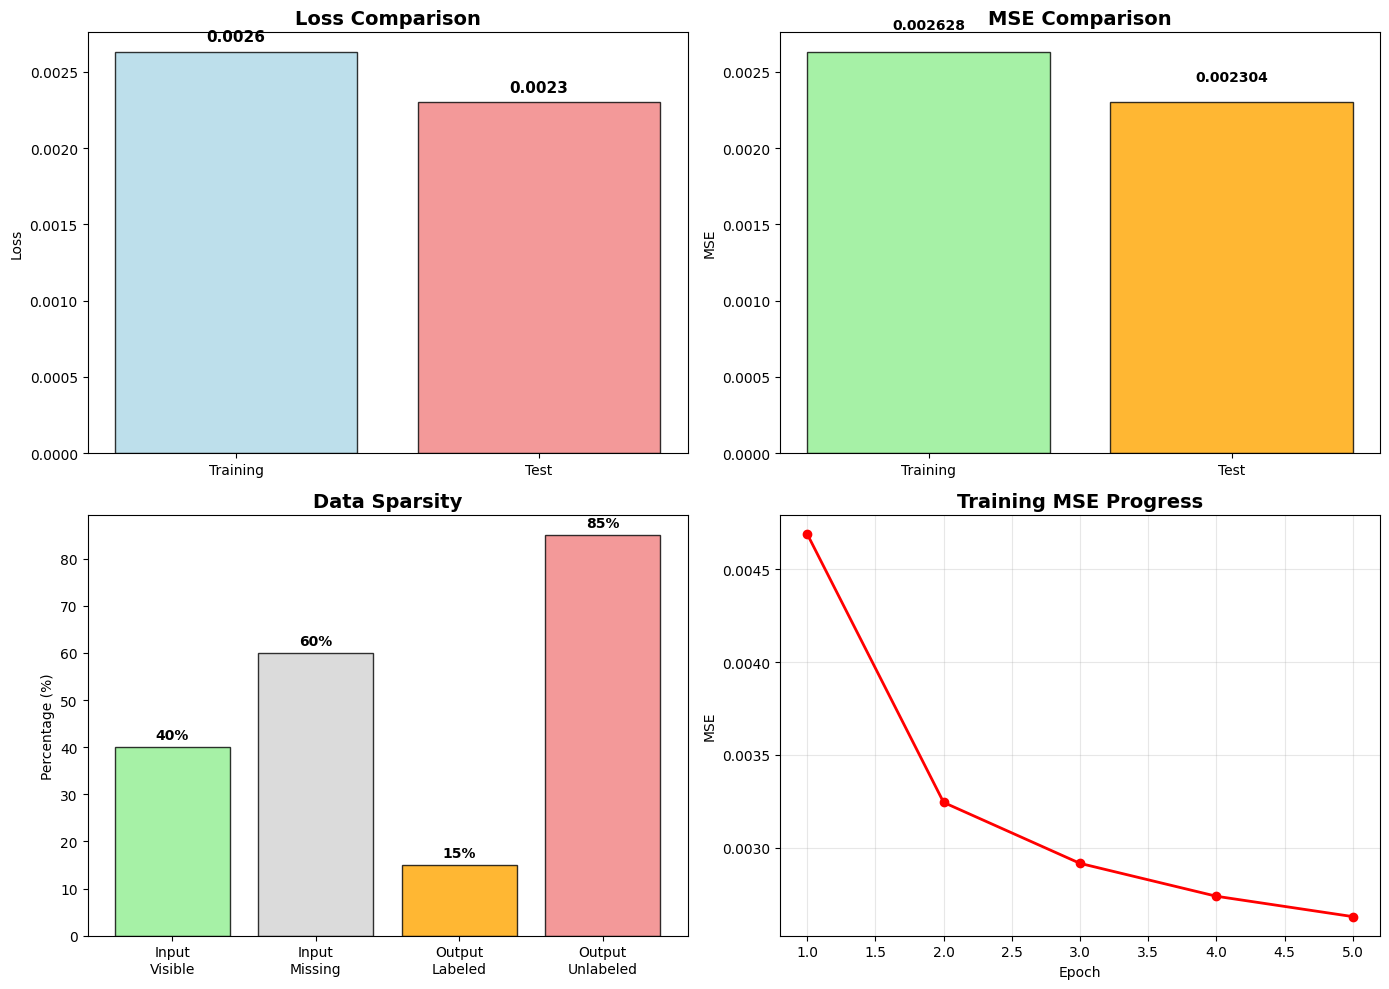


Sparse Pixel Training Results:
Final Training Loss: 0.0026
Final Test Loss: 0.0023
Training MSE: 0.002628
Training RMSE: 0.051264
Test MSE: 0.002304
Test RMSE: 0.048003
Test PSNR: 26.38 dB
Model Parameters: 1,928,483


In [27]:
# Create simple results visualization
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(14, 10))

# 1. Training vs Test Loss
if len(train_losses) > 0 and 'avg_test_loss' in globals():
    metrics = ['Training', 'Test']
    loss_values = [train_losses[-1], avg_test_loss]
    colors = ['lightblue', 'lightcoral']

    bars = ax1.bar(metrics, loss_values, color=colors, edgecolor='black', alpha=0.8)
    ax1.set_title('Loss Comparison', fontsize=14, fontweight='bold')
    ax1.set_ylabel('Loss')

    for bar, value in zip(bars, loss_values):
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height + height*0.02,
                 f'{value:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

# 2. Training vs Test MSE (better metric for regression)
if len(train_mse_values) > 0 and 'avg_test_mse' in globals():
    metrics = ['Training', 'Test']
    mse_values = [train_mse_values[-1], avg_test_mse]
    colors = ['lightgreen', 'orange']

    bars = ax2.bar(metrics, mse_values, color=colors, edgecolor='black', alpha=0.8)
    ax2.set_title('MSE Comparison', fontsize=14, fontweight='bold')
    ax2.set_ylabel('MSE')

    for bar, value in zip(bars, mse_values):
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height + height*0.05,
                 f'{value:.6f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# 3. Data Sparsity
categories = ['Input\nVisible', 'Input\nMissing', 'Output\nLabeled', 'Output\nUnlabeled']
sparsity_values = [
    input_sparsity * 100,
    (1 - input_sparsity) * 100,
    output_sparsity * 100,
    (1 - output_sparsity) * 100
]
colors = ['lightgreen', 'lightgray', 'orange', 'lightcoral']

bars = ax3.bar(categories, sparsity_values, color=colors, alpha=0.8, edgecolor='black')
ax3.set_title('Data Sparsity', fontsize=14, fontweight='bold')
ax3.set_ylabel('Percentage (%)')

for bar, value in zip(bars, sparsity_values):
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height + 1,
             f'{value:.0f}%', ha='center', va='bottom', fontweight='bold')

# 4. Training Progress (MSE over epochs)
if len(train_mse_values) > 0:
    epochs = range(1, len(train_mse_values) + 1)
    ax4.plot(epochs, train_mse_values, 'o-', linewidth=2, markersize=6, color='red')
    ax4.set_title('Training MSE Progress', fontsize=14, fontweight='bold')
    ax4.set_xlabel('Epoch')
    ax4.set_ylabel('MSE')
    ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nSparse Pixel Training Results:")
print("=" * 40)
if len(train_losses) > 0:
    print(f"Final Training Loss: {train_losses[-1]:.4f}")
if 'avg_test_loss' in globals():
    print(f"Final Test Loss: {avg_test_loss:.4f}")
if len(train_mse_values) > 0:
    print(f"Training MSE: {train_mse_values[-1]:.6f}")
    print(f"Training RMSE: {np.sqrt(train_mse_values[-1]):.6f}")
if 'avg_test_mse' in globals():
    print(f"Test MSE: {avg_test_mse:.6f}")
    print(f"Test RMSE: {np.sqrt(avg_test_mse):.6f}")
if 'test_psnr' in globals():
    print(f"Test PSNR: {test_psnr:.2f} dB")
print(f"Model Parameters: {total_params:,}")
print("=" * 40)

## 9. Sample Predictions

Let's visualize some sample predictions from our trained model.

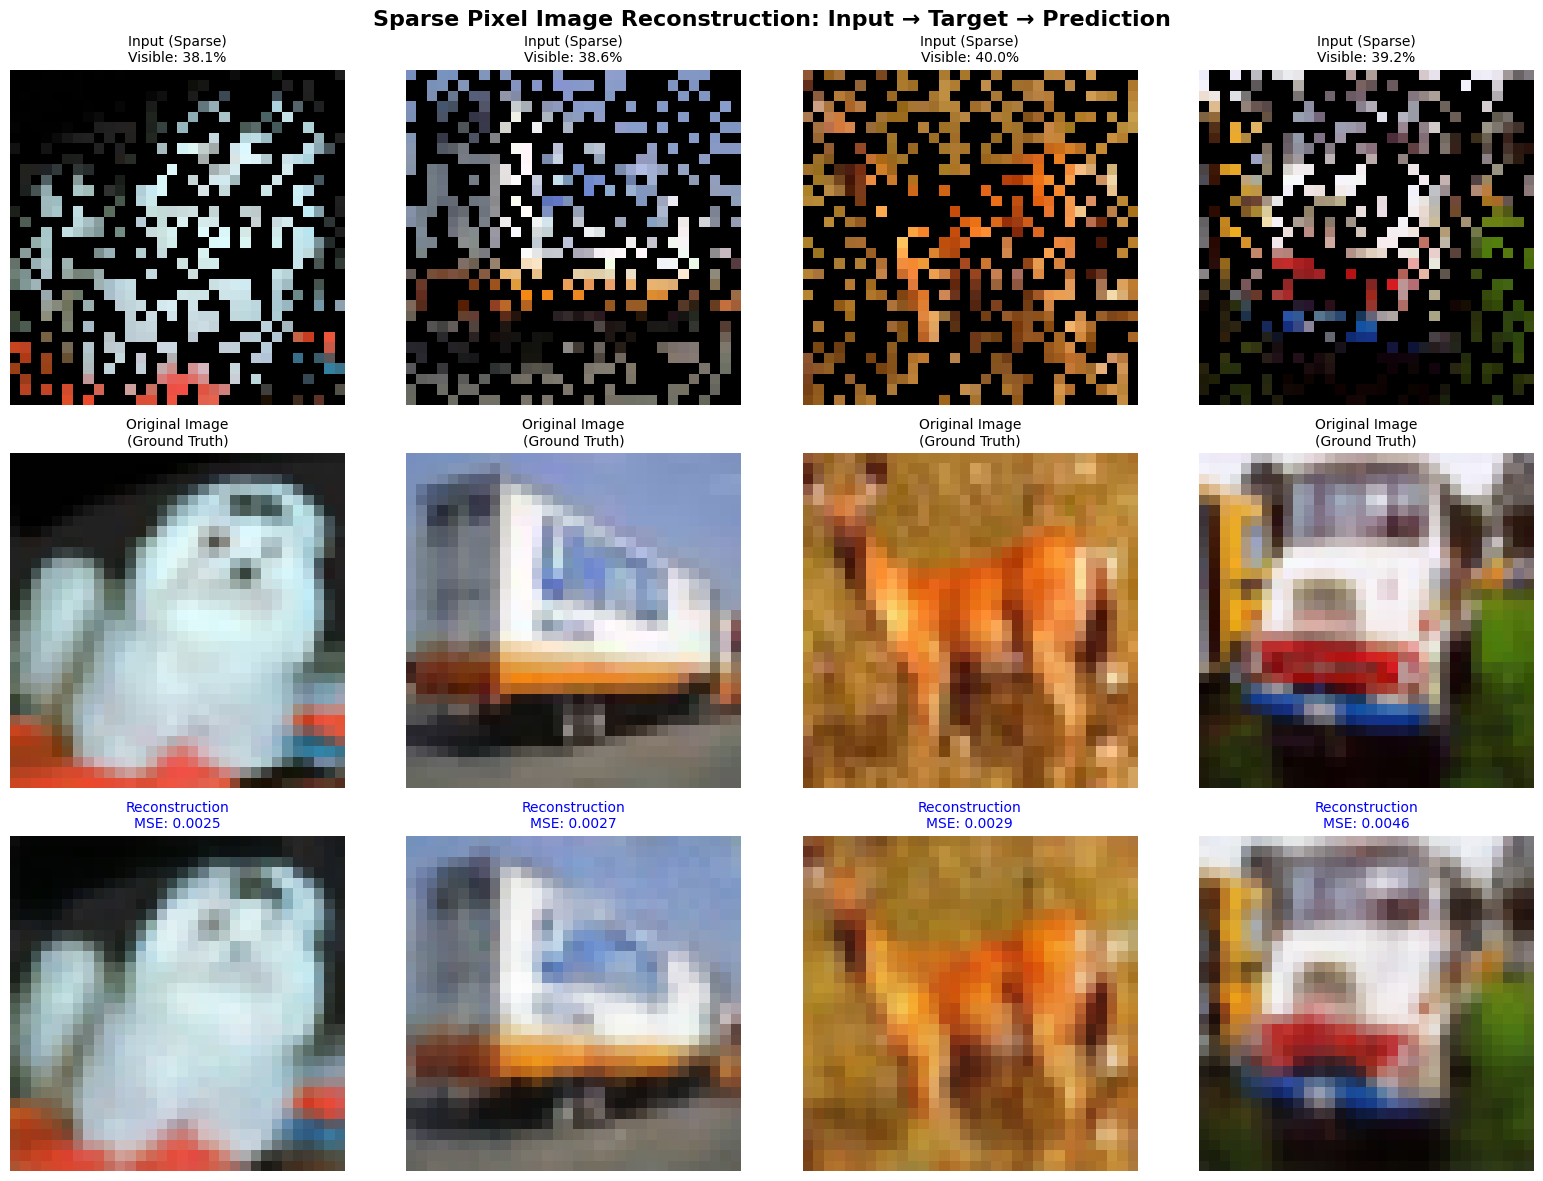

In [28]:
# Show sample sparse pixel reconstructions with original images
def show_sparse_reconstructions(model, dataset, num_samples=8):
    """Show model reconstructions comparing sparse input → original → prediction."""
    
    model.eval()
    
    fig, axes = plt.subplots(3, 4, figsize=(16, 12))
    
    # Create a clean CIFAR-10 dataset to get original images
    import torchvision.datasets as datasets
    
    # Load original CIFAR-10 test dataset (without any transforms except tensor conversion)
    original_transform = transforms.Compose([transforms.ToTensor()])
    original_dataset = datasets.CIFAR10(root='./data', train=False, transform=original_transform, download=False)
    
    # Get random samples
    indices = np.random.choice(len(dataset), num_samples, replace=False)
    
    with torch.no_grad():
        for i, idx in enumerate(indices):
            # Get sparse data from our dataset
            sparse_input, sparse_target, input_mask, output_mask = dataset[idx]
            
            # Get original clean image
            original_image, _ = original_dataset[idx]
            
            # Get prediction
            sparse_input_batch = sparse_input.unsqueeze(0).to(device)
            predicted_image = model(sparse_input_batch).squeeze(0).cpu()
            
            # Convert tensors for display
            sparse_input_np = sparse_input.permute(1, 2, 0).numpy()
            original_np = original_image.permute(1, 2, 0).numpy()
            predicted_np = predicted_image.permute(1, 2, 0).numpy()
            
            # Clamp values to [0,1] for display
            sparse_input_np = np.clip(sparse_input_np, 0, 1)
            original_np = np.clip(original_np, 0, 1)
            predicted_np = np.clip(predicted_np, 0, 1)
            
            # Display in rows: sparse input, original, prediction
            col = i % 4
            
            # Row 0: Sparse input
            axes[0, col].imshow(sparse_input_np)
            axes[0, col].set_title(f'Input (Sparse)\nVisible: {input_mask.float().mean()*100:.1f}%', 
                                  fontsize=10)
            axes[0, col].axis('off')
            
            # Row 1: Original image (ground truth)
            axes[1, col].imshow(original_np)
            axes[1, col].set_title('Original Image\n(Ground Truth)', fontsize=10)
            axes[1, col].axis('off')
            
            # Row 2: Prediction  
            axes[2, col].imshow(predicted_np)
            
            # Calculate MSE between prediction and original
            mse = F.mse_loss(predicted_image, original_image).item()
            axes[2, col].set_title(f'Reconstruction\nMSE: {mse:.4f}', 
                                  fontsize=10, color='blue')
            axes[2, col].axis('off')
    
    # Set row labels
    axes[0, 0].set_ylabel('Sparse Input', fontsize=12, fontweight='bold')
    axes[1, 0].set_ylabel('Original Image', fontsize=12, fontweight='bold')  
    axes[2, 0].set_ylabel('Reconstruction', fontsize=12, fontweight='bold')
    
    plt.suptitle('Sparse Pixel Image Reconstruction: Input → Target → Prediction', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

show_sparse_reconstructions(model, test_dataset, num_samples=8)